In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = df[df['job_title_short']== 'Data Analyst']

In [3]:
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg', 'median') 
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

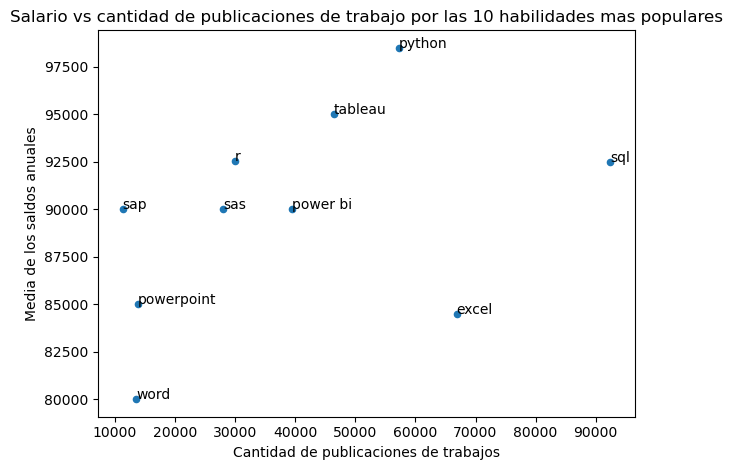

In [4]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Cantidad de publicaciones de trabajos')
plt.ylabel('Media de los saldos anuales')
plt.title('Salario vs cantidad de publicaciones de trabajo por las 10 habilidades mas populares')
plt.tight_layout()
for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
plt.show()